In [667]:
from datasets import load_dataset 

In [668]:
ds = load_dataset("imdb")

In [669]:
print(ds)

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})


In [670]:
train_df = ds["train"].to_pandas()

In [671]:
train_df.sample(10)

,text,label
1133,"First of all, write the script on a napkin. Wh...",0
20974,"OK, it was a good American Pie. Erick Stifler ...",1
11782,"William Lustig's followup to ""Maniac"" proves c...",0
22979,Almost 30 years later I recall this original P...,1
15424,Thanks should be given to the Hong Kong VCD/DV...,1
15503,This is one of those movies that you wish you ...,1
19640,"Although she is little known today, Deanna Dur...",1
2955,"This has to be creepiest, most twisted holiday...",0
1185,Spoilers I guess.<br /><br /> The absolutely a...,0
12955,My all-time favorite movie. Oscar-caliber work...,1


In [672]:
train_df['label'].value_counts()

label
0    12500
1    12500
Name: count, dtype: int64

In [673]:
import numpy as np

In [674]:
train_df['sentiment']=np.where(train_df['label']==1,'positive','negative')

In [675]:
train_df

,text,label,sentiment
0,I rented I AM CURIOUS-YELLOW from my video sto...,0,negative
1,"""I Am Curious: Yellow"" is a risible and preten...",0,negative
2,If only to avoid making this type of film in t...,0,negative
3,This film was probably inspired by Godard's Ma...,0,negative
4,"Oh, brother...after hearing about this ridicul...",0,negative
...,...,...,...
24995,A hit at the time but now better categorised a...,1,positive
24996,I love this movie like no other. Another time ...,1,positive
24997,This film and it's sequel Barry Mckenzie holds...,1,positive
24998,'The Adventures Of Barry McKenzie' started lif...,1,positive


In [676]:
train_df.sentiment.value_counts()

sentiment
negative    12500
positive    12500
Name: count, dtype: int64

<Axes: >

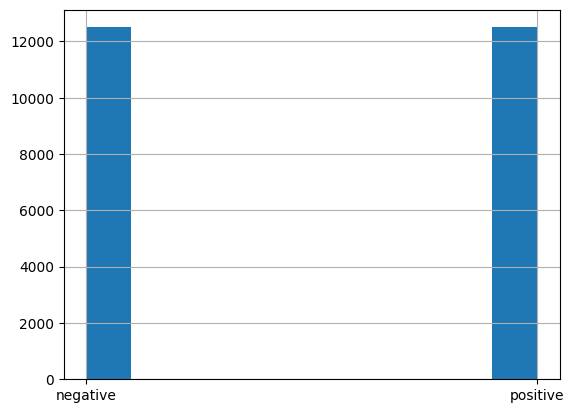

In [677]:
train_df.sentiment.hist()

In [678]:
from sklearn.model_selection import train_test_split

In [679]:
examples_df , gold_examples_df = train_test_split(train_df, test_size=0.2, random_state=42)

In [680]:
examples_df.shape, gold_examples_df.shape

((20000, 3), (5000, 3))

In [681]:
columns = ['text', 'sentiment']
gold_examples=(gold_examples_df[columns]
 .sample(20, random_state=42)
 .to_json(orient='records')
)

In [682]:
import json 

In [683]:
user_prompt_template = """Classify the sentiment of the following movie review as either positive or negative.

Review: {review}"""

In [684]:
json.loads(gold_examples)

[{'text': 'Like I said at the top, four stars just aren\'t enough. It\'s one of the best films I\'ve ever seen in my almost 17 years of life. For the people that don\'t really like it or understand it, you must not have a real appreciation for art or you might have a short attention span.<br /><br />Even if I haven\'t seen all his films yet, I\'d have to say that this is Spielberg at his peak. It\'s pretty sad to see that movies as great as "The Color Purple" don\'t come along too often \'cause I think all of us are in desperate need of first-class motion picture entertainment in these hard times.<br /><br />Movies like this are more than just movies; they\'re pieces of art that need to be appreciated more.<br /><br />The idea that it was nominated for 11 Oscars (even Best Picture of the Year) and didn\'t get one trophy is a sign of how blind and stupid Hollywood can be sometimes. Spielberg wasn\'t even nominated for Best Director! It should have swept the Oscars that year.<br /><br />

In [685]:
zero_shot_prompt_system_message = """You are a helpful assistant for sentiment analysis. You will be given a movie review and you need to classify it as either positive or negative."""

In [686]:
zero_shot_prompt=[
    {"role": "system", "content": zero_shot_prompt_system_message},
    
]

In [687]:
few_shot_prompt_system_message = """You are a helpful assistant for sentiment analysis. You will be given a movie review and you need to classify it as either positive or negative. """

In [688]:
examples_df

,text,label,sentiment
23311,I borrowed this movie despite its extremely lo...,1,positive
23623,After the unexpected accident that killed an i...,1,positive
1020,On the 1998 summer blockbuster hit BASEketball...,0,negative
12645,Can Scarcely Imagine a Better Movie Than This<...,1,positive
1533,A still famous but decadent actor (Morgan Free...,0,negative
...,...,...,...
21575,My discovery of the cinema of Jan Svankmajer o...,1,positive
5390,The story is similar to ET: an extraterrestria...,0,negative
860,I have read the novel Reaper of Ben Mezrich a ...,0,negative
15795,Went to see this finnish film and I've got to ...,1,positive


In [689]:
positive_reviews=examples_df[examples_df['sentiment']=='positive']

In [690]:
negative_reviews=examples_df[examples_df['sentiment']=='negative']

In [691]:
positive_reviews.shape, negative_reviews.shape

((10015, 3), (9985, 3))

In [692]:
negative_reviews

,text,label,sentiment
1020,On the 1998 summer blockbuster hit BASEketball...,0,negative
1533,A still famous but decadent actor (Morgan Free...,0,negative
3518,I am still shuddering at the thought of EVER s...,0,negative
483,"Within the realm of Science Fiction, two parti...",0,negative
7403,"When I saw the previews for this movie, I didn...",0,negative
...,...,...,...
6265,I saw this movie with the intention of not lik...,0,negative
11284,"The ""documentary"", and we use that term loosel...",0,negative
11964,Although a film with Bruce Willis is always wo...,0,negative
5390,The story is similar to ET: an extraterrestria...,0,negative


In [693]:
positive_reviews.shape, negative_reviews.shape

((10015, 3), (9985, 3))

In [694]:
positive_examples=positive_reviews[['text', 'sentiment']].sample(4).to_json(orient='records')

In [695]:
negative_examples=negative_reviews[['text', 'sentiment']].sample(4).to_json(orient='records')

In [696]:
json.loads(positive_examples)

[{'text': "This electrifying musical has more than a whiff of egotism from it's star, the musical genius that is Prince. The film is 90 or so minutes of posing but in truth it is easy to see why it is such a cult classic.<br /><br />Much like other films that centre around the struggling young musician trying to be big, this has a hint of drama in it to add a dimension to the musical numbers. While this film isn't as good as 8 mile as a recent example, this is entertaining none the less and the soundtrack is much better. On the dramatic side of things the story centres around the Kid (Prince) a young artist and regular spot at a club. The owner of the club is frustrated with the Kid's arrogance and little does the Kid know that he could soon be fired and replaced by a rival. One the side the Kid's parents are having trouble, with his dad abusing her violently. During the course of the film the Kid learns a few lessons in life, and learns to appreciate his friends more. It's all stuff w

In [697]:
json.loads(negative_examples)

[{'text': "Well this just maybe the worst movie ever at least the worst movie i have ever seen. They have tried out these 666 child of Satan the anti Christ kinda movies about 1000 times and none of them is good and this just maybe the worst of them. They think that it's going to be better movie as more they use that fake blood. This movie doesn't have any idea in it, actors and filming is just terrible. Cant even make out that 10 line minium of this movie. Really nothing to tell about but that it's just horrible. How they can make movies like that in their right mind just can't understand that. This cant be a Hollywood movie, is it? Just don't go watch this use your money more wisely.",
  'sentiment': 'negative'},
 {'text': 'I\'ll admit that I don\'t expect much from a Roger Corman film. Generally, I expect a lot of walking and bad scripts. Yet in this case, I am pleasantly surprised.<br /><br />The Gunslinger is a story of a woman (played by the spunky Beverly Garland) who takes over

In [698]:
import pandas as pd

In [699]:
examples=pd.concat([positive_reviews[['text', 'sentiment']].sample(4, random_state=42), negative_reviews[['text', 'sentiment']].sample(4, random_state=42)], ignore_index=True)

In [700]:
positive_reviews_df = positive_reviews[['text', 'sentiment']].sample(4, random_state=42)

In [701]:
positive_reviews_df.shape

(4, 2)

In [702]:
negative_reviews_df = negative_reviews[['text', 'sentiment']].sample(4, random_state=42)

In [703]:
negative_reviews_df.shape

(4, 2)

In [704]:
examples

,text,sentiment
0,Early Hollywood at it's best!! A classic Kipli...,positive
1,"Taiwanese director Ang Lee, whose previous fil...",positive
2,"I can't remember many details about the show, ...",positive
3,Like the gentle giants that make up the latter...,positive
4,no redeeming qualities can possibly be express...,negative
5,After the overrated success of Amenabar and Ba...,negative
6,This is the version that even the author hated...,negative
7,Despite the overwhelming cult following for th...,negative


In [705]:
examples=examples_df.sample(4*2 , replace=False )

In [706]:
examples

,text,label,sentiment
8650,"Dear Richard, I know we all loved you on Home ...",0,negative
870,"I wasn't sure how to rate this movie, since it...",0,negative
23315,"no, this is not supposed to be a high budget b...",1,positive
9629,There are a lot of highly talented filmmakers/...,0,negative
22700,A beautiful postcard of New York. The thing I ...,1,positive
17082,Eskimo is a serious movie about the cultural c...,1,positive
9825,I tend to love everything the great late Paul ...,0,negative
6027,"As a kid, my friends and I all believed that G...",0,negative


In [707]:
examples=examples_df.sample(4*2 , replace=False ).to_json(orient='records')

In [708]:
examples

'[{"text":"This definitely is NOT the intellectual film with profound mission, so I really don\'t think there is too much not to understand to in case you aren\'t Czech.<br \\/><br \\/>It\'s just a comedy. The humor is simple, pretty funny and sometimes, maybe, little morbid. Some actors and characters are very similar to Samot\\u00e1ri (2000) (Jir\\u00ed Mach\\u00e1cek, Ivan Trojan, Vladim\\u00edr Dlouh\\u00fd) so the authors are. But it doesn\'t matter, the genre is really different and these two films shouldn\'t be compared in this way. Jedna ruka netlesk\\u00e1 won\'t try to give you a lesson, it will try to make you laugh and there is some chance it will succeed.<br \\/><br \\/>Not bad film, not the ingenious one, but I enjoyed it. Some scenes are truly worth seeing.","label":1,"sentiment":"positive"},{"text":"An absolutely atrocious adaptation of the wonderful children\'s book. Crude and inappropriate humor, some scary parts, and a sickening side story about the mom\'s boyfriend 

In [709]:
json.loads(examples)

[{'text': "This definitely is NOT the intellectual film with profound mission, so I really don't think there is too much not to understand to in case you aren't Czech.<br /><br />It's just a comedy. The humor is simple, pretty funny and sometimes, maybe, little morbid. Some actors and characters are very similar to Samotári (2000) (Jirí Machácek, Ivan Trojan, Vladimír Dlouhý) so the authors are. But it doesn't matter, the genre is really different and these two films shouldn't be compared in this way. Jedna ruka netleská won't try to give you a lesson, it will try to make you laugh and there is some chance it will succeed.<br /><br />Not bad film, not the ingenious one, but I enjoyed it. Some scenes are truly worth seeing.",
  'label': 1,
  'sentiment': 'positive'},
 {'text': "An absolutely atrocious adaptation of the wonderful children's book. Crude and inappropriate humor, some scary parts, and a sickening side story about the mom's boyfriend wanting to send the boy away to military 

In [710]:
def create_examples(dataset,n=4):
    positive_reviews_df=dataset[dataset['sentiment']=='positive'][['text', 'sentiment']].sample(n, random_state=42)
    negative_reviews_df=dataset[dataset['sentiment']=='negative'][['text', 'sentiment']].sample(n, random_state=42)
    examples_df=pd.concat([positive_reviews_df, negative_reviews_df], ignore_index=True)
    examples=examples_df.sample(2*n, replace=False ).to_json(orient='records')
    return examples_df.to_json(orient='records')

In [711]:
examples=create_examples(examples_df,n=6)


In [712]:
examples

'[{"text":"Early Hollywood at it\'s best!! A classic Kipling poem is transformed into an epic adventure featuring memorable performances by a stellar cast. I think the measure of a good film is how many times you can watch it and still genuinely enjoy it. I\'ve seen it a dozen times and still cry at the end and, admit it, you do too!!","sentiment":"positive"},{"text":"Taiwanese director Ang Lee, whose previous films include \'Sense and Sensibility\' and \'The Ice Storm\', turned to the American Civil War for his latest feature. Based on a novel by Daniel Woodrell, it follows the exploits of a group of Southern guerrillas, known as bushwhackers, as they fight their Northern equivalents, the jayhawkers in the backwater of Missouri.<br \\/><br \\/>As one might expect, there is plenty of visceral action, but the focus is on the tension that the war put on the young men who fought it - many of whom were fighting against their former neighbours and even family. Jake Roedel (Tobey Maguire) is

In [713]:
examples_df.shape

(20000, 3)

In [714]:
def create_prompt(system_message, examples, user_prompt_template):
    prompt=[
        {"role": "system", "content": system_message},
       
    ]
    for example in json.loads(examples ):
        review=example['text']
        sentiment=example['sentiment']
        prompt.append({"role": "user", "content": user_prompt_template.format(review=review)})
        prompt.append({"role": "assistant", "content": sentiment})
    return prompt

In [715]:
few_shot_prompt=create_prompt(few_shot_prompt_system_message, examples, user_prompt_template)

In [716]:
few_shot_prompt

[{'role': 'system',
  'content': 'You are a helpful assistant for sentiment analysis. You will be given a movie review and you need to classify it as either positive or negative. '},
 {'role': 'user',
  'content': "Classify the sentiment of the following movie review as either positive or negative.\n\nReview: Early Hollywood at it's best!! A classic Kipling poem is transformed into an epic adventure featuring memorable performances by a stellar cast. I think the measure of a good film is how many times you can watch it and still genuinely enjoy it. I've seen it a dozen times and still cry at the end and, admit it, you do too!!"},
 {'role': 'assistant', 'content': 'positive'},
 {'role': 'user',
  'content': "Classify the sentiment of the following movie review as either positive or negative.\n\nReview: Taiwanese director Ang Lee, whose previous films include 'Sense and Sensibility' and 'The Ice Storm', turned to the American Civil War for his latest feature. Based on a novel by Daniel W

In [717]:
cot_few_shot_prompt_system_message = """You are a helpful assistant for sentiment analysis. You will be given a movie review and you need to classify it as either positive or negative. Think step by step.
Instructions:
1. Read the movie review carefully.
2. Identify the sentiment expressed in the review (positive or negative).
3. Provide a clear explanation for your classification.
"""

In [718]:
cot_few_shot_prompt=create_prompt(cot_few_shot_prompt_system_message, examples, user_prompt_template)

In [719]:
cot_few_shot_prompt

[{'role': 'system',
  'content': 'You are a helpful assistant for sentiment analysis. You will be given a movie review and you need to classify it as either positive or negative. Think step by step.\nInstructions:\n1. Read the movie review carefully.\n2. Identify the sentiment expressed in the review (positive or negative).\n3. Provide a clear explanation for your classification.\n'},
 {'role': 'user',
  'content': "Classify the sentiment of the following movie review as either positive or negative.\n\nReview: Early Hollywood at it's best!! A classic Kipling poem is transformed into an epic adventure featuring memorable performances by a stellar cast. I think the measure of a good film is how many times you can watch it and still genuinely enjoy it. I've seen it a dozen times and still cry at the end and, admit it, you do too!!"},
 {'role': 'assistant', 'content': 'positive'},
 {'role': 'user',
  'content': "Classify the sentiment of the following movie review as either positive or neg

In [720]:
from sklearn.metrics import f1_score

In [721]:
def evaluate_prompt(prompt, gold_examples , user_prompt_template,review ,llm):
    
    predicted_sentiments,ground_truth_sentiments=[],[]



    for example in json.loads(gold_examples):

       review=example['text']

       sentiment=example['sentiment']



       user_input={"role": "user", "content": user_prompt_template.format(review=example['text'])}

       try:

           resp= llm.invoke(prompt + [user_input])

           if 'negative' in resp.content.strip().lower():

               predicted='negative'

           elif 'positive' in resp.content.strip().lower():

                predicted='positive'            

           else:

                   predicted='unknown'

           predicted_sentiments.append(sentiment)
           ground_truth_sentiments.append(sentiment)
           print(f"Review: {review}\nPredicted Sentiment: {predicted}\nGround Truth Sentiment: {sentiment}\n")

       except Exception as e :

               print(e) 

               continue
       return f1_score(ground_truth_sentiments, predicted_sentiments, average='micro')

In [722]:
from dotenv.ipython import load_dotenv
load_dotenv(override=True)

True

In [723]:
from langchain_openai import ChatOpenAI

In [724]:
llm=ChatOpenAI(model="gpt-4o", temperature=0)

In [725]:
import os
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

load_dotenv(override=True)

True

In [726]:
from langchain_ollama import ChatOllama

In [727]:
llm2 = ChatOllama(model="llama3.2", temperature=0)

In [728]:
def evaluate_prompt(prompt, gold_examples, user_prompt_template, llm):
    predicted_sentiments, ground_truth_sentiments = [], []

    for example in json.loads(gold_examples):
        review = example["text"]
        sentiment = example["sentiment"]

        user_input = {
            "role": "user",
            "content": user_prompt_template.format(review=review)
        }

        try:
            resp = llm.invoke(prompt + [user_input])
            content = resp.content.strip().lower()

            if "negative" in content:
                predicted = "negative"
            elif "positive" in content:
                predicted = "positive"
            else:
                predicted = "unknown"

            predicted_sentiments.append(predicted)
            ground_truth_sentiments.append(sentiment)

            print(f"Review: {review}\nPredicted: {predicted}\nGround Truth: {sentiment}\n")

        except Exception as e:
            print(e)
            continue

    return f1_score(ground_truth_sentiments, predicted_sentiments, average="micro")

In [730]:
evaluate_prompt(few_shot_prompt, gold_examples, user_prompt_template, llm2)

Review: Like I said at the top, four stars just aren't enough. It's one of the best films I've ever seen in my almost 17 years of life. For the people that don't really like it or understand it, you must not have a real appreciation for art or you might have a short attention span.<br /><br />Even if I haven't seen all his films yet, I'd have to say that this is Spielberg at his peak. It's pretty sad to see that movies as great as "The Color Purple" don't come along too often 'cause I think all of us are in desperate need of first-class motion picture entertainment in these hard times.<br /><br />Movies like this are more than just movies; they're pieces of art that need to be appreciated more.<br /><br />The idea that it was nominated for 11 Oscars (even Best Picture of the Year) and didn't get one trophy is a sign of how blind and stupid Hollywood can be sometimes. Spielberg wasn't even nominated for Best Director! It should have swept the Oscars that year.<br /><br />The film clearl

1.0

In [732]:
from tqdm import tqdm

In [734]:
num_eval_runs=3
performances=[]
for _ in tqdm(range(num_eval_runs)):
   examples = create_examples(examples_df,n=4)
   fsp = create_prompt(few_shot_prompt_system_message, examples, user_prompt_template)
   performance = evaluate_prompt(fsp, gold_examples, user_prompt_template, llm2)
   performances.append(performance)

mean = np.array(performances).mean() 
print(f"mean : ${mean}")
std = np.array(performances).std()
print(f"std : ${std}")

  0%|          | 0/3 [00:00<?, ?it/s]

Review: Like I said at the top, four stars just aren't enough. It's one of the best films I've ever seen in my almost 17 years of life. For the people that don't really like it or understand it, you must not have a real appreciation for art or you might have a short attention span.<br /><br />Even if I haven't seen all his films yet, I'd have to say that this is Spielberg at his peak. It's pretty sad to see that movies as great as "The Color Purple" don't come along too often 'cause I think all of us are in desperate need of first-class motion picture entertainment in these hard times.<br /><br />Movies like this are more than just movies; they're pieces of art that need to be appreciated more.<br /><br />The idea that it was nominated for 11 Oscars (even Best Picture of the Year) and didn't get one trophy is a sign of how blind and stupid Hollywood can be sometimes. Spielberg wasn't even nominated for Best Director! It should have swept the Oscars that year.<br /><br />The film clearl

 33%|███▎      | 1/3 [29:11<58:22, 1751.19s/it]

Review: This is the movie I've seen more times than any other (I believe I saw it on average once every year since it was released). And every time I see it, it is equally fantastic and always reveals something new to me. The cast was most probably a combination of the very best there ever was in ex Yu cinematography. This movie is an absolute must for any self respecting movie lover. In the same league: Maratonci trce pocasni krug, Balkanski spijun and Otac na sluzbenom putu. This is a poker of movies everyone should have in his private video collection.
Predicted: positive
Ground Truth: positive

Review: Like I said at the top, four stars just aren't enough. It's one of the best films I've ever seen in my almost 17 years of life. For the people that don't really like it or understand it, you must not have a real appreciation for art or you might have a short attention span.<br /><br />Even if I haven't seen all his films yet, I'd have to say that this is Spielberg at his peak. It's p

 67%|██████▋   | 2/3 [46:31<22:12, 1332.80s/it]

Review: This is the movie I've seen more times than any other (I believe I saw it on average once every year since it was released). And every time I see it, it is equally fantastic and always reveals something new to me. The cast was most probably a combination of the very best there ever was in ex Yu cinematography. This movie is an absolute must for any self respecting movie lover. In the same league: Maratonci trce pocasni krug, Balkanski spijun and Otac na sluzbenom putu. This is a poker of movies everyone should have in his private video collection.
Predicted: positive
Ground Truth: positive

Review: Like I said at the top, four stars just aren't enough. It's one of the best films I've ever seen in my almost 17 years of life. For the people that don't really like it or understand it, you must not have a real appreciation for art or you might have a short attention span.<br /><br />Even if I haven't seen all his films yet, I'd have to say that this is Spielberg at his peak. It's p

100%|██████████| 3/3 [1:01:10<00:00, 1223.67s/it]

Review: This is the movie I've seen more times than any other (I believe I saw it on average once every year since it was released). And every time I see it, it is equally fantastic and always reveals something new to me. The cast was most probably a combination of the very best there ever was in ex Yu cinematography. This movie is an absolute must for any self respecting movie lover. In the same league: Maratonci trce pocasni krug, Balkanski spijun and Otac na sluzbenom putu. This is a poker of movies everyone should have in his private video collection.
Predicted: positive
Ground Truth: positive

mean : $1.0
std : $0.0
